In [1]:
from typing import Dict, Any
import matplotlib.pyplot as plt
from pytorch3dunet.datasets.dsb import Standard_TIF_Dataset

from model_ranking import (
    get_unique_colourmap
)

INFO: P [MainThread] 2025-09-23 15:09:18,545 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/predictor.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# MicroSAM Dataset

In [2]:
transformer_cfg: Dict[str, Any] = {
    "raw": [
        {"name": "ToTensor", "expand_dims": True},
    ],
    "label": [
        {"name": "ToTensor", "expand_dims": True},
    ],
}

In [5]:
microSAM_dataset = Standard_TIF_Dataset(
    image_dir="/g/kreshuk/talks/consistency_results/Instance_segmentation/Covid_IF/Micro_SAM/consistency/vit_b_lm/none/predictions",
    mask_dir="/g/kreshuk/talks/data/covid_if",
    phase="eval",
    transformer_config=transformer_cfg,
    expand_dims=True,
    global_norm=False,
    mask_key="labels/cells/s0",
    image_key="prediction"
)
print(len(microSAM_dataset))

49


torch.Size([1, 1, 1024, 1024]) torch.Size([1, 1, 1024, 1024])


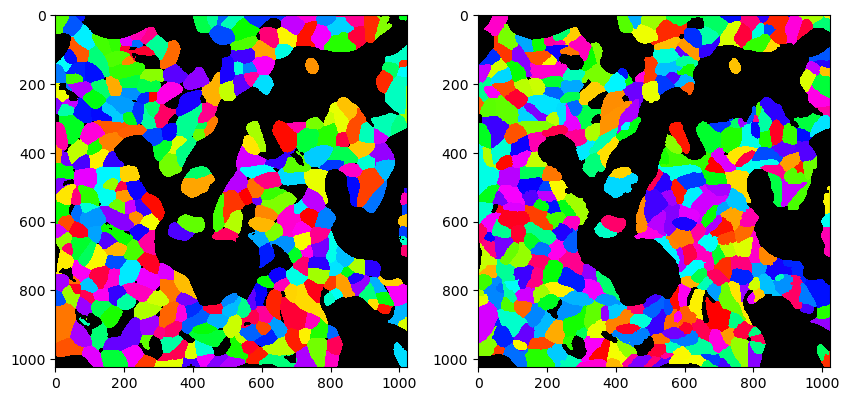

In [6]:
pert_pred, NA_pred = microSAM_dataset[1]
print(pert_pred.shape, NA_pred.shape)
_, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(pert_pred.numpy().squeeze(), cmap=get_unique_colourmap(pert_pred.numpy().squeeze()), interpolation='nearest')
axs[1].imshow(NA_pred.numpy().squeeze(), cmap=get_unique_colourmap(NA_pred.numpy().squeeze()), interpolation='nearest')
plt.show()

# Cellpose-SAM Dataset

In [15]:
transformer_cfg: Dict[str, Any] = {
    "raw": [
        {"name": "ToTensor", "expand_dims": True},
    ],
    "label": [
        {"name": "ToTensor", "expand_dims": True},
    ],
}

In [16]:
microSAM_dataset = Standard_TIF_Dataset(
    image_dir="/g/kreshuk/talks/consistency_results/Instance_segmentation/Covid_IF/Cellpose_SAM/consistency/cpsam/none/predictions",
    mask_dir="/g/kreshuk/talks/data/covid_if",
    phase="eval",
    transformer_config=transformer_cfg,
    expand_dims=True,
    global_norm=False,
    image_key="masks",
    mask_key="labels/cells/s0"
)
print(len(microSAM_dataset))

49


torch.Size([1, 1, 1024, 1024]) torch.Size([1, 1, 1024, 1024])


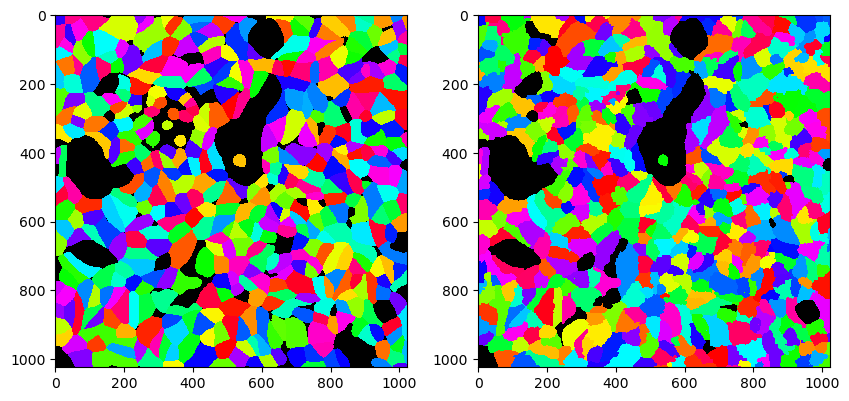

torch.Size([1, 1, 1024, 1024]) torch.Size([1, 1, 1024, 1024])


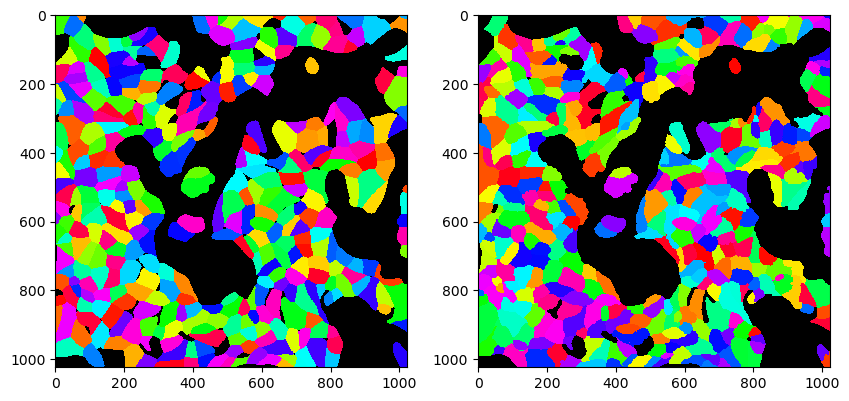

In [ ]:
for i in range(2):
    pert_pred, NA_pred = microSAM_dataset[i]
    print(pert_pred.shape, NA_pred.shape)
    _, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(pert_pred.numpy().squeeze(), cmap=get_unique_colourmap(pert_pred.numpy().squeeze()), interpolation='nearest')
    axs[1].imshow(NA_pred.numpy().squeeze(), cmap=get_unique_colourmap(NA_pred.numpy().squeeze()), interpolation='nearest')
    plt.show()

# check consistency Calculation

In [1]:
from model_ranking import (
    ConsistencyConfig,
    get_consistency_loaders,
    calc_consistency_score,
    calculate_per_patch_consistency,
    CovidIFTargetConfig,
    AdaptedRandErrorConsisConfig,
    TIFEvalDatasetConfig,
    get_output_dir
)
from typing import Dict, Any
from numpy.typing import NDArray
from typing import List, Any
from pathlib import Path
from natsort import natsorted

INFO: P [MainThread] 2025-09-23 15:23:43,169 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/predictor.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
consistency_metric: Dict[str, Any] = {
    "save_key": "AdaRand_consis",
    "save_mask": False,
    "mask_threshold": 0.5,
    "overwrite_score": False,
    "bckg_consistency": False,
    "name": "AdaptedRandError",
    "num_dilations": 1,
    "num_erosions": 1,
}

In [3]:
consis_metric_cfg = AdaptedRandErrorConsisConfig.model_validate(consistency_metric)

In [7]:
base_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation"

In [8]:
dir_path = get_output_dir(
    source="Micro_SAM",
    target="Covid_IF",
    model_name="vit_b_lm",
    approach="consistency",
    result_type=None,
    base_seg_folder=base_path
)
print(dir_path)

/g/kreshuk/talks/consistency_results/Instance_segmentation/Covid_IF/Micro_SAM/consistency/vit_b_lm


In [5]:
pred_dir_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Covid_IF/Micro_SAM/consistency/vit_b_lm/gauss_s01-012/predictions"
none_pred_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Covid_IF/Micro_SAM/consistency/vit_b_lm/none/predictions"
consis_loader_cfg = CovidIFTargetConfig().consis_dataloader_instance.create_consis_config(
    perturbed_dir=(pred_dir_path,),
    unperturbed_dir=(none_pred_path,),
)

In [6]:
config_data = ConsistencyConfig(
    consistency_dataloader=consis_loader_cfg,
    consistency_metric=consis_metric_cfg,
)

In [7]:
consis_scores: List[NDArray[Any]] = []
consis_masks: List[NDArray[Any]] = []
for dataloader in get_consistency_loaders(consis_loader_cfg):
        scores, masks = calc_consistency_score(dataloader, config_data)
        consis_scores.append(scores)
        consis_masks.append(masks)

100%|██████████| 49/49 [00:04<00:00, 11.67it/s]


In [8]:
i =2
consis_scores[0][i].shape
print(consis_scores[0][i])
consis_PP = calculate_per_patch_consistency(
    consis_scores[0][i].squeeze(), 
    config_data.consistency_metric.save_key
)
consis_PP.shape
print(consis_PP)

[0.6863088  0.48421958 0.2319907 ]
[0.6863088  0.48421958 0.2319907 ]


In [10]:
if isinstance(consis_loader_cfg.eval_dataset, TIFEvalDatasetConfig):
    pred_dir = consis_loader_cfg.eval_dataset.eval.image_dir[0]
    pred_paths = natsorted(list(Path(pred_dir).glob("*.h5")))
    assert consis_scores[0] is not None, "Scores are not available"
    assert len(pred_paths) == len(
        consis_scores[0]
    ), "Number of predictions and scores differ"

In [ ]:
masks.shape

(49, 1, 1, 1024, 1024)

In [16]:
scores.shape

(49, 3)

In [9]:
from model_ranking import extract_filename

In [13]:
path = Path("/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/EPFL_to_EPFL_gap/consistency/P_full/E_model_NA2/norm_Normalize/gauss_a01-02/predictions/test_predictions.h5")
path2 = Path("/g/kreshuk/talks/consistency_results/Instance_segmentation/Covid_IF/Micro_SAM/consistency/vit_b_lm/gauss_a001-003/predictions/sample_000.h5")

print(path.stem)
filename = extract_filename(path)
print(filename)

test_predictions
test
